In [1]:
import gdown
import zipfile
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.applications import MobileNetV2, InceptionV3
from tensorflow.keras.layers import Input, Rescaling, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tkinter import Tk
from tkinter.filedialog import askopenfilename
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# -------- Download Dataset --------
drive_url = "https://drive.google.com/uc?id=1duu-eAn9EZPECYT-8TwlRI9g4kG2YGMJ"
zip_path = "British Currency.zip"
gdown.download(drive_url, zip_path, quiet=False)

# Unzip the dataset
extract_path = "British Currency"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, "train")
valid_dir = os.path.join(extract_path, "valid")
test_dir  = os.path.join(extract_path, "test")

Downloading...
From: https://drive.google.com/uc?id=1duu-eAn9EZPECYT-8TwlRI9g4kG2YGMJ
To: /content/British Currency.zip
100%|██████████| 4.87M/4.87M [00:00<00:00, 10.6MB/s]


In [4]:
# -------- Dataset Loaders --------
IMG_SIZE = (299, 299)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

num_classes = len(train_ds.class_names)

Found 378 files belonging to 10 classes.
Found 27 files belonging to 10 classes.
Found 27 files belonging to 10 classes.


In [5]:
# -------- Model Setup --------

# Define MobileNetV2 model
def build_mobilenetv2_model():
    base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base_model.trainable = False
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [6]:
# Define InceptionV3 model
def build_inceptionv3_model():
    base_model = InceptionV3(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base_model.trainable = False
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [16]:
# -------- Train Both Models --------
mobilenetv2_model = build_mobilenetv2_model()
inceptionv3_model = build_inceptionv3_model()

# Train MobileNetV2
mobilenetv2_history = mobilenetv2_model.fit(
    train_ds, validation_data=valid_ds, epochs=40
)

# Train InceptionV3
inceptionv3_history = inceptionv3_model.fit(
    train_ds, validation_data=valid_ds, epochs=40
)

/tmp/ipython-input-1196614741.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")


Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.2177 - loss: 2.2244 - val_accuracy: 0.2963 - val_loss: 1.9595
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5266 - loss: 1.6744 - val_accuracy: 0.3704 - val_loss: 1.7649
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6135 - loss: 1.3719 - val_accuracy: 0.3333 - val_loss: 1.5651
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6695 - loss: 1.2184 - val_accuracy: 0.4444 - val_loss: 1.4568
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6893 - loss: 1.1134 - val_accuracy: 0.5185 - val_loss: 1.3351
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7486 - loss: 0.9889 - val_accuracy: 0.5185 - val_loss: 1.2646
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7946 - loss: 0.8930 - val_accuracy: 0.4815 - val_loss: 1.1703
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8215 - loss: 0.8486 - val_accuracy: 0.5185 - val_loss:

In [23]:
from sklearn.metrics import precision_score, f1_score
import numpy as np

# Function to get predictions and calculate metrics for a given model
def calculate_metrics(model, test_ds):
    true_labels = []
    predicted_labels = []

    # Loop through the test dataset and get true and predicted labels
    for images, labels in test_ds:
        true_labels.extend(labels.numpy())
        predictions = model.predict(images)
        predicted_labels.extend(np.argmax(predictions, axis=1))

    # Calculate Precision, F1-Score, and Accuracy
    precision = precision_score(true_labels, predicted_labels, average='weighted') * 100
    f1 = f1_score(true_labels, predicted_labels, average='weighted') * 100
    accuracy = np.mean(np.array(predicted_labels) == np.array(true_labels)) * 100

    return accuracy, precision, f1

# Calculate accuracy, precision, and F1-score for MobileNetV2
mobilenetv2_accuracy, mobilenetv2_precision, mobilenetv2_f1 = calculate_metrics(mobilenetv2_model, test_ds)

# Calculate accuracy, precision, and F1-score for InceptionV3
inceptionv3_accuracy, inceptionv3_precision, inceptionv3_f1 = calculate_metrics(inceptionv3_model, test_ds)

# Print the results in percentage format
print(f"MobileNetV2 Accuracy: {mobilenetv2_accuracy:.2f}%")
print(f"MobileNetV2 Precision: {mobilenetv2_precision:.2f}%")
print(f"MobileNetV2 F1-Score: {mobilenetv2_f1:.2f}%")
print(f"InceptionV3 Accuracy: {inceptionv3_accuracy:.2f}%")
print(f"InceptionV3 Precision: {inceptionv3_precision:.2f}%")
print(f"InceptionV3 F1-Score: {inceptionv3_f1:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
MobileNetV2 Accuracy: 62.96%
MobileNetV2 Precision: 68.52%
MobileNetV2 F1-Score: 60.29%
InceptionV3 Accuracy: 40.74%
InceptionV3 Precision: 29.07%
InceptionV3 F1-Score: 32.68%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


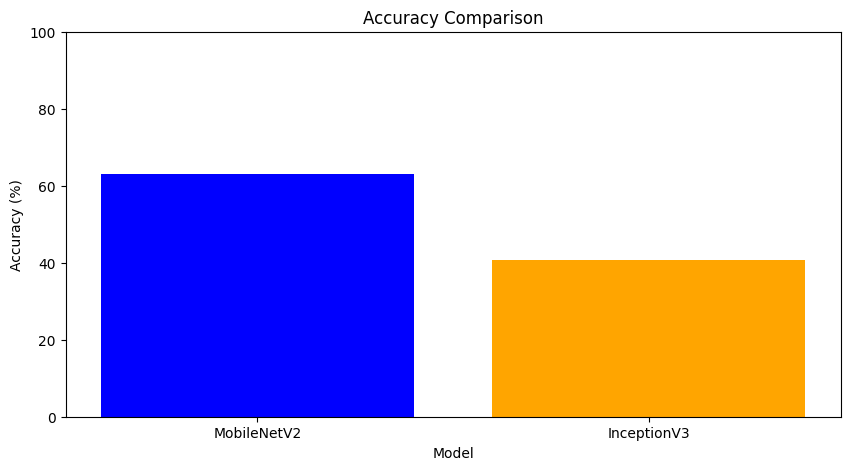

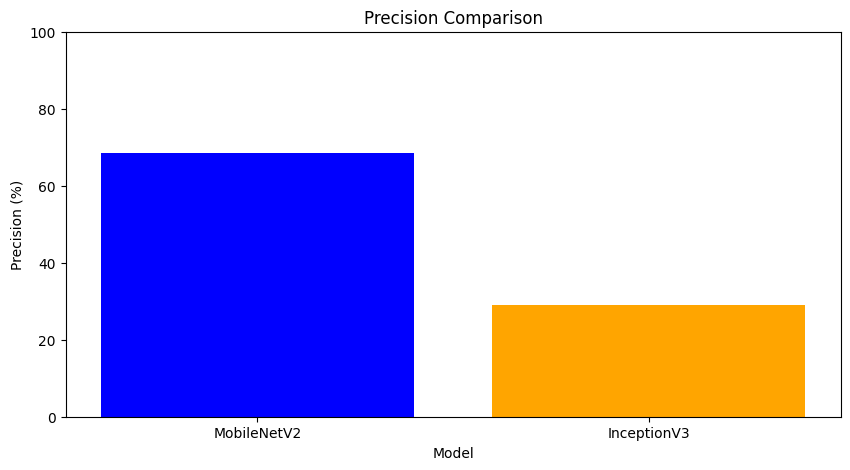

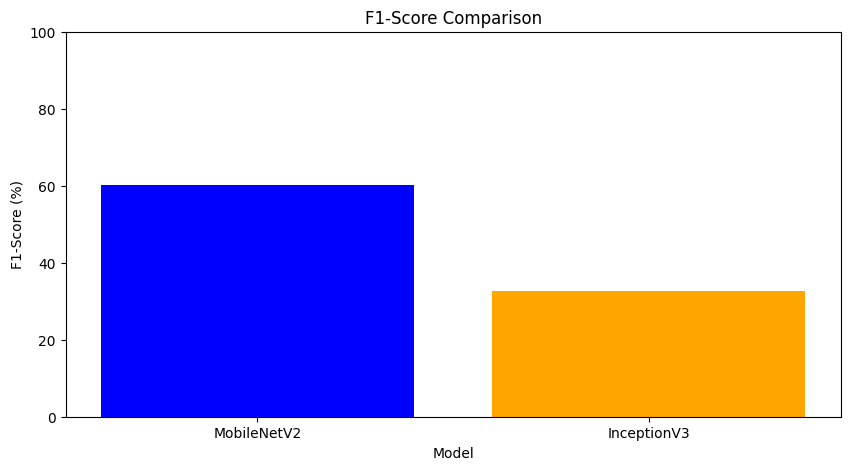

In [24]:
import matplotlib.pyplot as plt

# Create bar charts for Accuracy, Precision, and F1-Score
models = ['MobileNetV2', 'InceptionV3']
accuracy_values = [mobilenetv2_accuracy, inceptionv3_accuracy]
precision_values = [mobilenetv2_precision, inceptionv3_precision]
f1_values = [mobilenetv2_f1, inceptionv3_f1]

# Plotting Accuracy
plt.figure(figsize=(10, 5))
plt.bar(models, accuracy_values, color=['blue', 'orange'])
plt.title('Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis to range from 0 to 100 for percentage
plt.show()

# Plotting Precision
plt.figure(figsize=(10, 5))
plt.bar(models, precision_values, color=['blue', 'orange'])
plt.title('Precision Comparison')
plt.xlabel('Model')
plt.ylabel('Precision (%)')
plt.ylim(0, 100)  # Set y-axis to range from 0 to 100 for percentage
plt.show()

# Plotting F1-Score
plt.figure(figsize=(10, 5))
plt.bar(models, f1_values, color=['blue', 'orange'])
plt.title('F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score (%)')
plt.ylim(0, 100)  # Set y-axis to range from 0 to 100 for percentage
plt.show()

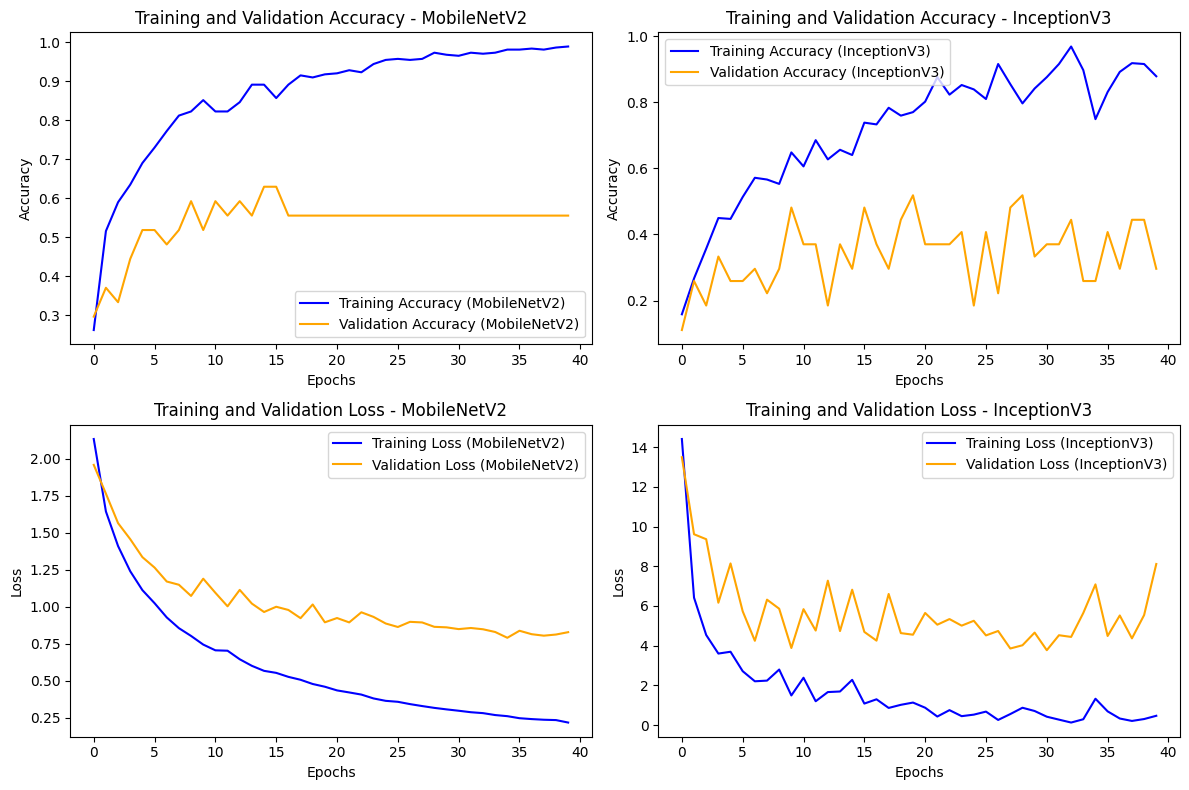

In [19]:
def plot_comparison(mobilenetv2_history, inceptionv3_history):
    # Create a 2x2 grid of plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Training vs Validation Accuracy
    axes[0, 0].plot(mobilenetv2_history.history['accuracy'], label='Training Accuracy (MobileNetV2)', color='blue')
    axes[0, 0].plot(mobilenetv2_history.history['val_accuracy'], label='Validation Accuracy (MobileNetV2)', color='orange')
    axes[0, 0].set_title('Training and Validation Accuracy - MobileNetV2')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()

    axes[0, 1].plot(inceptionv3_history.history['accuracy'], label='Training Accuracy (InceptionV3)', color='blue')
    axes[0, 1].plot(inceptionv3_history.history['val_accuracy'], label='Validation Accuracy (InceptionV3)', color='orange')
    axes[0, 1].set_title('Training and Validation Accuracy - InceptionV3')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    # Training vs Validation Loss
    axes[1, 0].plot(mobilenetv2_history.history['loss'], label='Training Loss (MobileNetV2)', color='blue')
    axes[1, 0].plot(mobilenetv2_history.history['val_loss'], label='Validation Loss (MobileNetV2)', color='orange')
    axes[1, 0].set_title('Training and Validation Loss - MobileNetV2')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()

    axes[1, 1].plot(inceptionv3_history.history['loss'], label='Training Loss (InceptionV3)', color='blue')
    axes[1, 1].plot(inceptionv3_history.history['val_loss'], label='Validation Loss (InceptionV3)', color='orange')
    axes[1, 1].set_title('Training and Validation Loss - InceptionV3')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

# Call this function after training both models
plot_comparison(mobilenetv2_history, inceptionv3_history)

In [20]:
# -------- Function to Get Predictions and True Labels --------
def get_predictions_and_labels(model, dataset):
    # Get the true labels from the dataset
    true_labels = []
    predicted_labels = []

    # Iterate over the dataset and get predictions
    for images, labels in dataset:
        true_labels.extend(labels.numpy())  # Append true labels
        predictions = model.predict(images)  # Get model predictions
        predicted_labels.extend(np.argmax(predictions, axis=1))  # Get the predicted class index

    return np.array(true_labels), np.array(predicted_labels)

In [21]:
# -------- Function to Plot Confusion Matrix --------
def plot_confusion_matrix(true_labels, predicted_labels, class_names, model_name):
    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


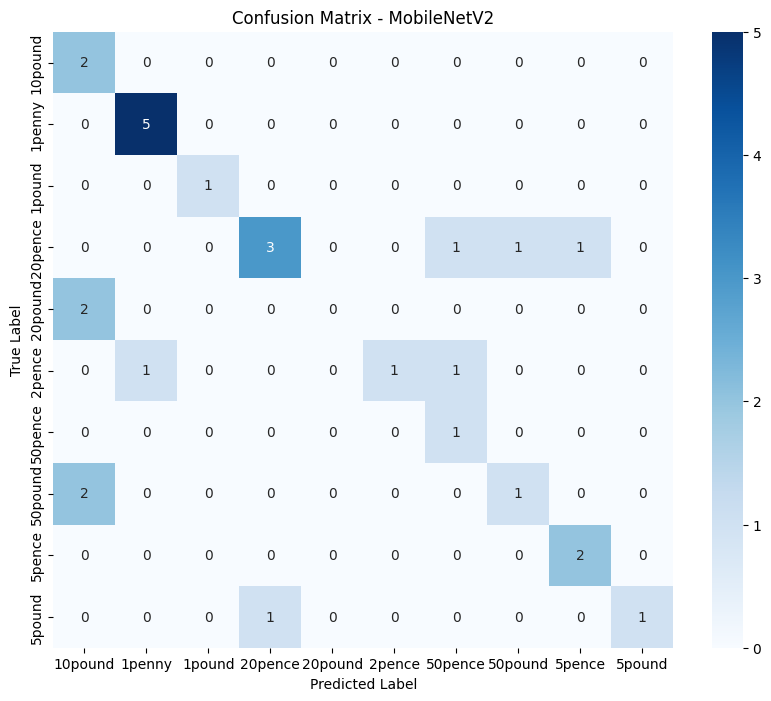

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


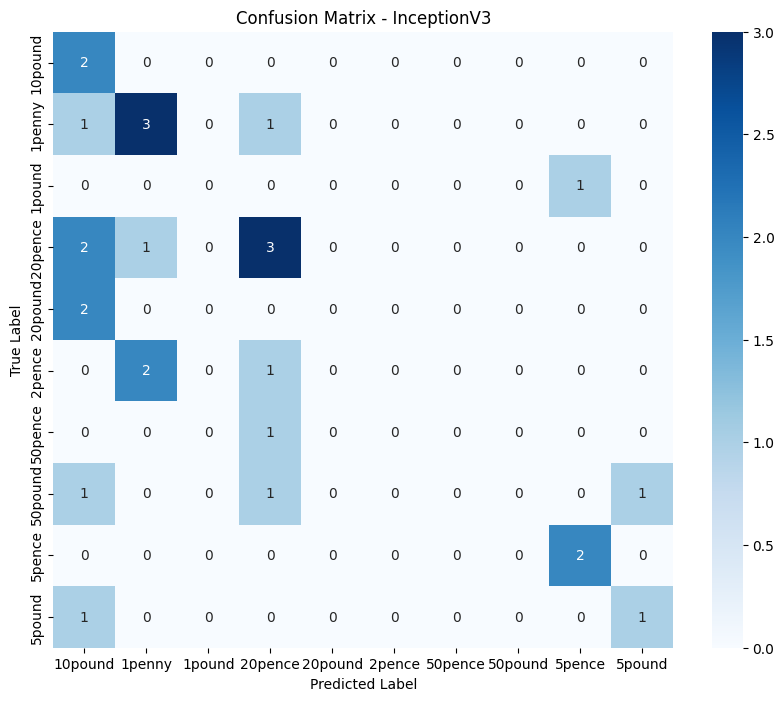

In [22]:
# -------- Get Predictions and Plot Confusion Matrices --------

# 1. Get true labels and predictions for MobileNetV2
mobilenetv2_true_labels, mobilenetv2_predicted_labels = get_predictions_and_labels(mobilenetv2_model, test_ds)

# 2. Plot the confusion matrix for MobileNetV2
plot_confusion_matrix(mobilenetv2_true_labels, mobilenetv2_predicted_labels, train_ds.class_names, "MobileNetV2")

# 3. Get true labels and predictions for InceptionV3
inceptionv3_true_labels, inceptionv3_predicted_labels = get_predictions_and_labels(inceptionv3_model, test_ds)

# 4. Plot the confusion matrix for InceptionV3
plot_confusion_matrix(inceptionv3_true_labels, inceptionv3_predicted_labels, train_ds.class_names, "InceptionV3")

In [13]:
# -------- Function to Load and Preprocess Image for Prediction --------
def load_and_preprocess_image(img_path, target_size=(299, 299)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize the image
    return img_array

In [14]:
# -------- Predict Currency Value from Single Image --------
def predict_currency_value(model, img_path):
    # Preprocess the image
    img_array = load_and_preprocess_image(img_path)

    # Get the model's prediction
    prediction = model.predict(img_array)

    # Get the predicted class (the index with the highest probability)
    predicted_class_index = np.argmax(prediction, axis=1)[0]

    # Map the class index to the currency value (using train_ds.class_names)
    class_names = train_ds.class_names  # Use class_names from the dataset
    predicted_currency = class_names[predicted_class_index]

    return predicted_currency

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


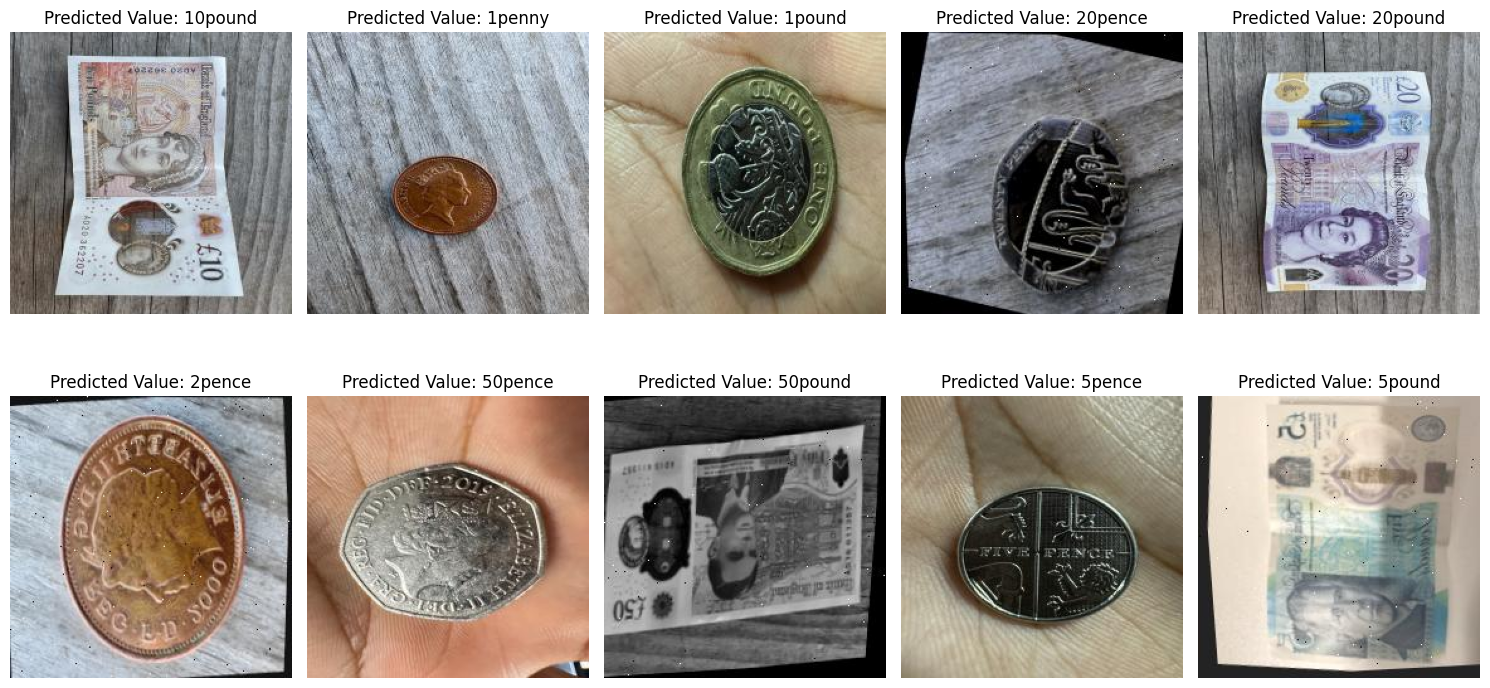

In [15]:
# -------- Display One Image for Each Class --------
def display_one_image_per_class(model):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8))
    axes = axes.flatten()

    for i, class_name in enumerate(train_ds.class_names):
        # Get the image file path for this class
        class_dir = os.path.join(train_dir, class_name)
        class_image_files = os.listdir(class_dir)

        # Pick one image from the class directory
        img_path = os.path.join(class_dir, class_image_files[0])  # Take the first image in the class folder

        # Predict the currency value for the image
        predicted_currency = predict_currency_value(model, img_path)

        # Display the image and the predicted currency
        img = image.load_img(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Predicted Value: {class_name}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# -------- Example Usage to Display Images of All Classes --------
# Use either MobileNetV2 or InceptionV3
model = mobilenetv2_model  # Or use inceptionv3_model

# Display one image per class and its prediction
display_one_image_per_class(model)